<a href="https://colab.research.google.com/github/jmcardenas8/ML-project-mental-health/blob/main/notebook/Proyecto_IA_Salud_Mental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

___
___
# **Análisis Global de Salud Mental**
<br>

___
___
<br><br>

Proyecto - Talento Tech, Bootcamp Inteligencia Artificial, explorador - basico G485

Integrantes:
* Juan Manuel Cardenas Mancipe
* Jeferson del Río Herrera
* Manuela López Caro
* Carla Zapata Valencia
<br>

___
<br>

Bibliotecas python para Machine learning, aprendizaje supervizado

In [ ]:
# Basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import time
import kagglehub       # biblioteca kaggle
import requests        # api json, metadata
import os              # interactuar con sistema operativo


# libraries for data preprocessing & ML
from sklearn.preprocessing import LabelEncoder, MinMaxScaler # transformacion de variables
from sklearn.model_selection import train_test_split  # division de datos
from sklearn.pipeline import Pipeline # permite aplicar modelos, y se puede hacer una tuberia de modelos que se apliquen en serie a los datos

# libraries for model evaluation (metrics)
from sklearn.metrics import ( accuracy_score, # exactitud
                              precision_score,
                              recall_score,
                              f1_score,
                              classification_report,
                              confusion_matrix,
                              roc_curve,
                              auc,
                              RocCurveDisplay,)
from sklearn.model_selection import cross_val_score, KFold # Cross validation



# Clasification Models
from sklearn.linear_model import LogisticRegression  # LR
from sklearn.neighbors import KNeighborsClassifier   # KNN
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB # Probabilisticos
from sklearn.tree import DecisionTreeClassifier           # DT   |
from sklearn.ensemble import (RandomForestClassifier,     # RF   |
                              GradientBoostingClassifier) # GB   | Arboles y Ensambles
from xgboost import XGBClassifier    # Xtream GB                 |
from lightgbm import LGBMClassifier  # Light GB                  |
from sklearn.svm import SVC # Maquinas de soporte vectorial


# Regresion Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet # Lineales
from sklearn.preprocessing import PolynomialFeatures # Polinomiales
from sklearn.tree import DecisionTreeRegressor                                # |
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor # | Arboles y Ensambles
from xgboost import XGBRegressor                                              # |
from lightgbm import LGBMRegressor                                            # |
from sklearn.neighbors import KNeighborsRegressor # Basado en Distancia
from sklearn.neural_network import MLPRegressor   # Red neuronal
from sklearn.svm import SVR

## **Objetivo**

Analizar la relación entre los indicadores de salud mental con otras variables a nivel mundial.

<br>


## **Fuentes de Datos**

Algunos sitios web y repositorios de datos, abiertos y compatibles con Python, en formato(CSV, XLSX o JSON). En este trabajo solo se exploraron los 2 primeros, y se descartó el primero por falta de datasets completos.

> 1. Our World in Data (OWID) https://ourworldindata.org/
>
> 2. kaggle https://www.kaggle.com/
>
> 3. Google dataset search
> 4. Data gov
> 5. open data UE
> 6. World bank open data
> 7. UNICEF Data
> 8. Open Alex



<br>


### **kaggle: Mental Health Dataset**

Se analizó un siguiente dataset, junto a un notebook guia sobre prediccion con machine learning.

* Dataset: "Mental Health Dataset", autor: Bhavik Jikadar https://www.kaggle.com/datasets/bhavikjikadara/mental-health-dataset
* Notebook guia: "ML Applications to Mental Health Diagnosis", autor: Max Boonjindasup. https://www.kaggle.com/code/maxboonjindasup/ml-applications-to-mental-health-diagnosis
* En el presente notebook tambien se empleó la asistencia de chatbots como chat-GPT para el entendimiento de funciones que desconociamos y para algunas formas de graficacion.



<br><br>



___
### **EDA**

Carga del dataset desde la biblioteca oficial "KaggleHub" que permite acceder e interactuar con datasets, modelos, y notebooks de kaggle.



In [ ]:
# descarga del dataset
path = kagglehub.dataset_download("bhavikjikadara/mental-health-dataset")

100%|██████████| 1.95M/1.95M [00:00<00:00, 108MB/s]

Extracting files...


Los Datasets pueden ser una colección de archivos, por lo que hay que revisar cuantos y que archivos tienen.

In [ ]:
# revisar que archivos tiene el dataset
for fil in os.listdir(path):
    print(fil)

Mental Health Dataset.csv


In [ ]:
# lectura del ds con pandas
df = pd.read_csv(f'{path}/Mental Health Dataset.csv')
df.head()

,Timestamp,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
0,8/27/2014 11:29,Female,United States,Corporate,NaN,No,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Not sure
1,8/27/2014 11:31,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,No
2,8/27/2014 11:32,Female,United States,Corporate,NaN,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes
3,8/27/2014 11:37,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,Maybe,Yes
4,8/27/2014 11:43,Female,United States,Corporate,No,Yes,Yes,1-14 days,Yes,No,Yes,Medium,No,No,Yes,No,Yes


#### **Descripcion de columnas**

* **Gender**: The classification of a person as male or female.

* **Country**: The place where a person lives. This is relevant because mental health resources and cultural attitudes toward mental health can vary by country.

* **Occupation**: A person's usual or principal work or business. Occupation can influence stress levels and access to mental health resources.

* **Self-employed**: Indicates whether a person is working for themselves or has their own business, rather than working for an employer.

* **Family history**: A record of the relationships among family members along with their medical histories. Family history of mental health issues can indicate potential genetic or environmental factors.

* **Treatment**: Indicates whether a person is currently undergoing treatment for mental health issues.

* **Growing Stress**: Indicates whether a person's stress level is increasing over time.

* **Changes Habits**: This seems incomplete. It could refer to changes in behavior or habits that may indicate shifts in mental health.

* **Mental_Health_History**: A record of a person's mental health history, including any previous diagnoses or treatments.

* **Mood_Swings**: Fluctuations in a person's mood, which can be indicative of various mental health conditions.

* **Coping_Struggles**: Difficulties a person may have in coping with stressors or mental health challenges.

* **Work_Interest**: Level of interest or engagement in work or activities, which can be affected by mental health.

* **Social_Weakness**: Weaknesses or difficulties in social interactions or relationships, which can be impacted by mental health issues.

* **Mental_Health_Interview**: It seems like this could refer to a structured interview or assessment related to mental health.

* **Care_Options**: Options available for seeking care or treatment for mental health issues, such as therapy, medication, or support groups.

In [ ]:
# Tipo de datos que contienen las columnas
df.dtypes

,0
Timestamp,object
Gender,object
Country,object
Occupation,object
self_employed,object
family_history,object
treatment,object
Days_Indoors,object
Growing_Stress,object
Changes_Habits,object


todos son categoricos, tipo "object"

In [ ]:
# Tamano del data set
n_muestras = df.shape[0]

# Cantidad de variables (columnas)
n_variables = df.shape[1]

print(f"Numero de filas: {n_muestras}")
print(f"Numero de columnas: {n_variables}")

Numero de filas: 292364
Numero de columnas: 17


#### **Eliminacion de NaN**

In [ ]:
# cuantos valores NaN hay
df.isnull().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,5202
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


In [ ]:
# porcentaje de NaNs
nans = df.isnull()['self_employed'].sum()
nans_perc = nans/df.shape[0]*100

print(f'Casillas NaN en self_employed {nans_perc:.2f}%')

Casillas NaN en self_employed 1.78%


Las casillas que tienen valores NaN representan el 1.78% del total de las personas encuestadas, como representan menos del 2% del total, se decidio eliminar esas filas asociadas.


In [ ]:
df.dropna(inplace = True)

In [ ]:
df.isnull().sum()

,0
Timestamp,0
Gender,0
Country,0
Occupation,0
self_employed,0
family_history,0
treatment,0
Days_Indoors,0
Growing_Stress,0
Changes_Habits,0


#### **Elimiacion de filas duplicadas**


> la funcion "duplicated" de pandas, calcula el numero de filas duplicadas

In [ ]:
df.duplicated().sum()
print(f'Hay {df.duplicated().sum()} filas duplicadas')

Hay 2304 filas duplicadas


In [ ]:
df.drop_duplicates(inplace = True)

#### **Eliminacion de columnas no necesarias**


> El valor del tiempo en el que se realizo la encuesta no tiene mucha informacion util, salvo que se realizo entre 2014,2015,2016, y es la columna con la que se diferencian diferentes filas, pero para el analisis no será necesaria.

In [ ]:
df.drop(columns = "Timestamp", inplace = True)

**Paises encuestados**

In [ ]:
import plotly.express as px

# conteo de encuestados por pais
country = np.array(df['Country'].unique())
count = np.array(df['Country'].value_counts()[ df['Country'].unique() ])

# dataframe a graficar
df_graph = pd.DataFrame({"country":country, "count": count})

# Figura
fig = px.choropleth(
    df_graph,
    locations="country",
    locationmode="country names",  # se puede usar ISO-3
    color="count",
    color_continuous_scale="Viridis",
    title="Número de encuestados por país"
)

fig.show()

**Histogramas de cada variable**

In [ ]:
def top_10_bar(category, x_rotation = 45):
    """
    Plots a bar plot showing the distribution of a categorical variable for the top 10 categories.

    Args:
        category (str): The column name for the categorical variable to plot.
        x_rotation (int, optional): The number of degrees to rotate the x-axis labels. Defaults to 45.
    """
    # Get the top 10 categories and their counts in a DataFrame
    top_10_df = df[category].value_counts().head(10).reset_index()

    # Plotting
    sns.barplot(data = top_10_df, x = category, y = "count")
    plt.title(category)
    plt.xticks(rotation = x_rotation)
    plt.ylabel("Count")
    plt.show()
    print("\n")

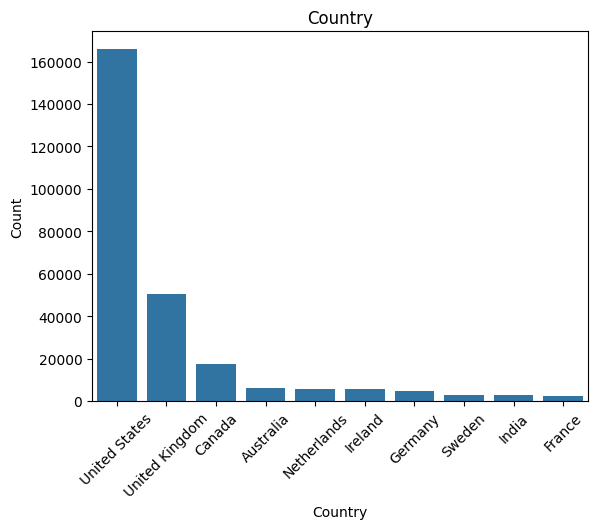

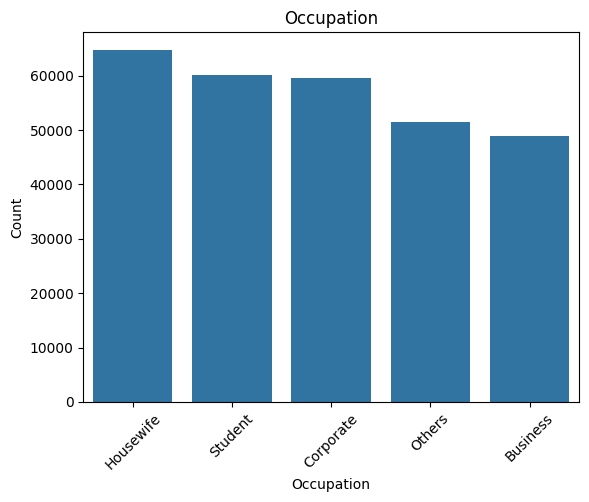

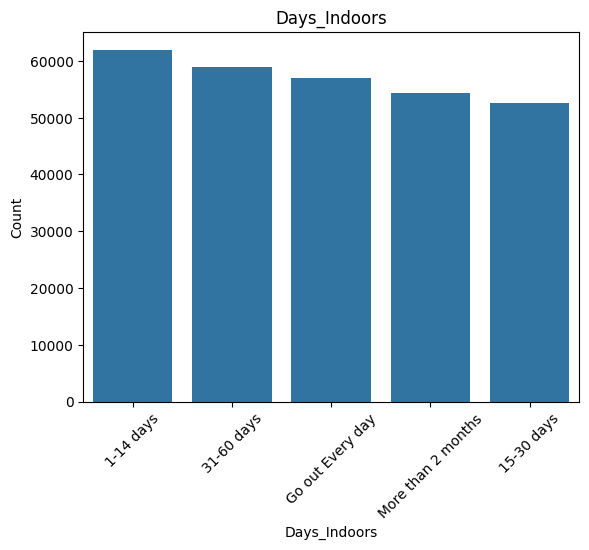

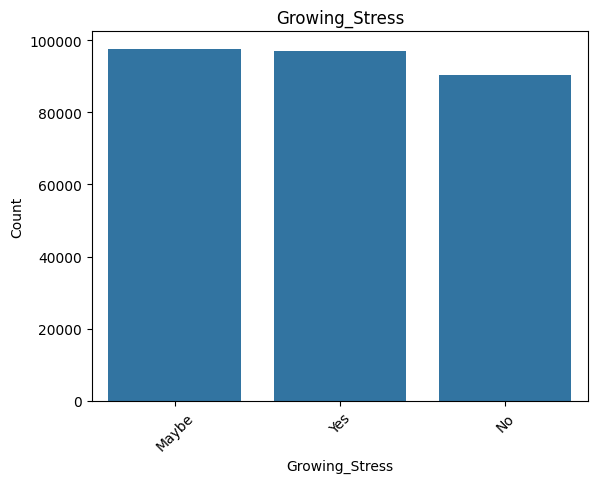

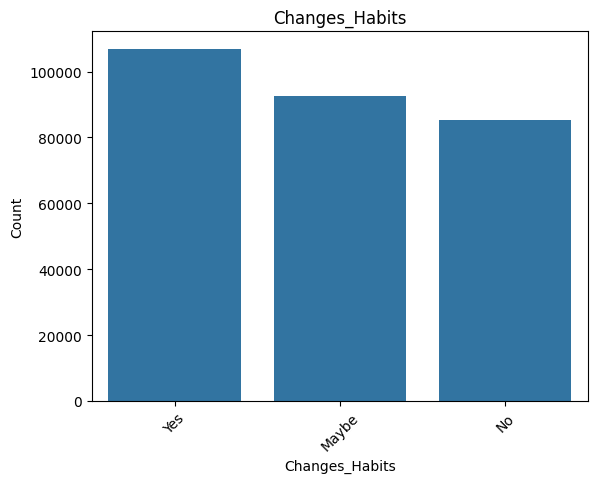

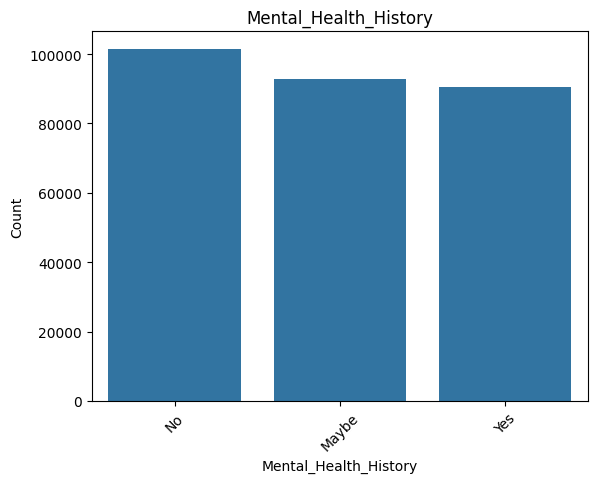

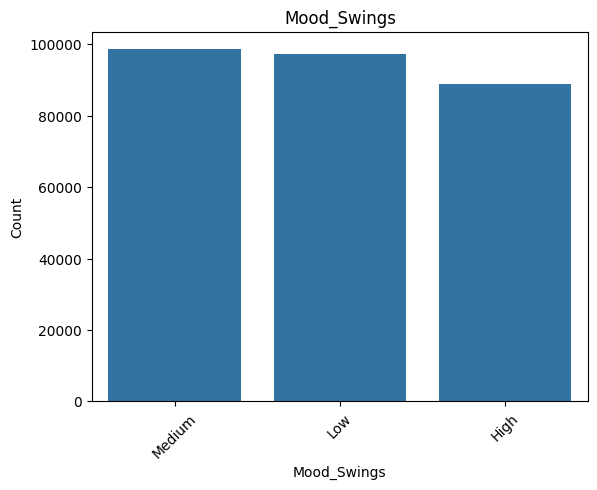

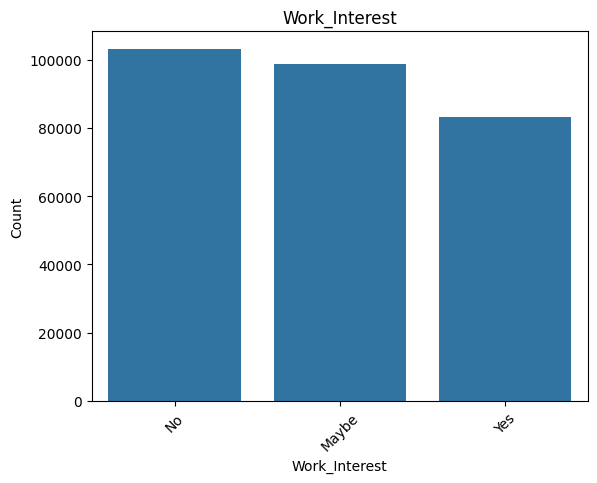

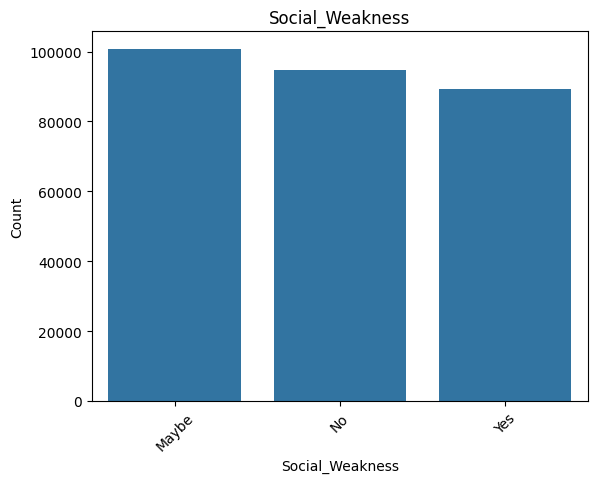

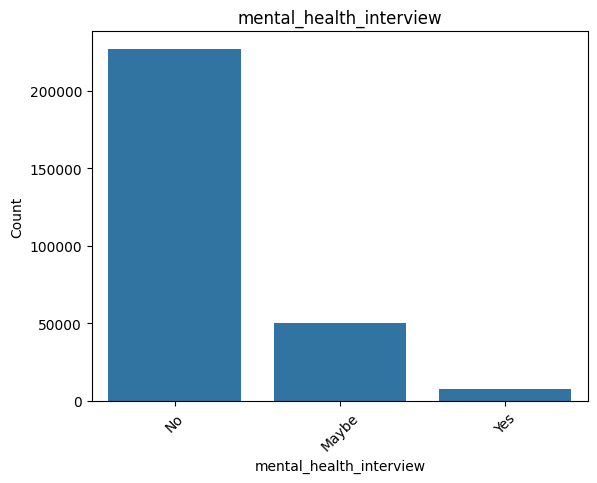

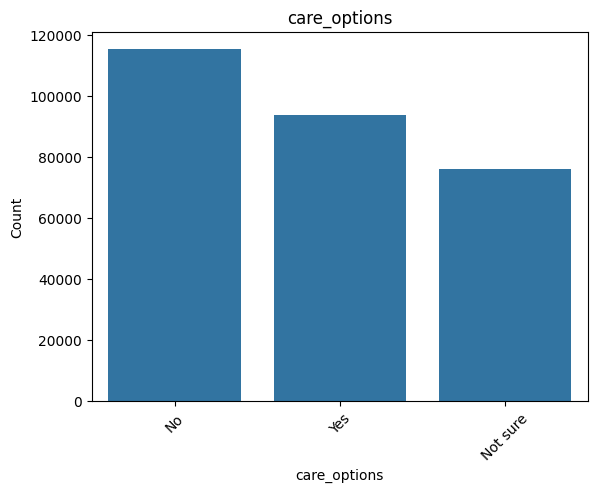

In [ ]:
for column in df.columns:
    if df[column].nunique() > 2:
        top_10_bar(column)

___
### **Procesamiento de datos**


codificacion de datos categoricos en numericos

In [ ]:
encoded_df = df.copy() # df nuevo codigicado
encoders = {}   # como se codifica cada columna

for col in df.columns: # para cada columna
    le = LabelEncoder()                         # codificador
    encoded_df[col] = le.fit_transform(df[col]) # codifica columna
    encoders[col] = le                          # codificacion

encoded_df.head()

# # # Forma mas rapida, pero se pierde como se codifico cada columna
# # Create a LabelEncoder object
# le = LabelEncoder()
# # Applica LabelEncoder directamente cada columna
# encoded_df = df.apply(le.fit_transform)

,Gender,Country,Occupation,self_employed,family_history,treatment,Days_Indoors,Growing_Stress,Changes_Habits,Mental_Health_History,Mood_Swings,Coping_Struggles,Work_Interest,Social_Weakness,mental_health_interview,care_options
3,0,34,1,0,1,1,0,2,1,2,2,0,1,2,0,2
4,0,34,1,0,1,1,0,2,1,2,2,0,1,2,1,2
5,0,25,1,0,0,1,0,2,1,2,2,0,1,2,0,1
6,0,0,1,0,1,1,0,2,1,2,2,0,1,2,1,1
7,0,34,1,0,0,0,0,2,1,2,2,0,1,2,1,0


**Matriz de correlacion**

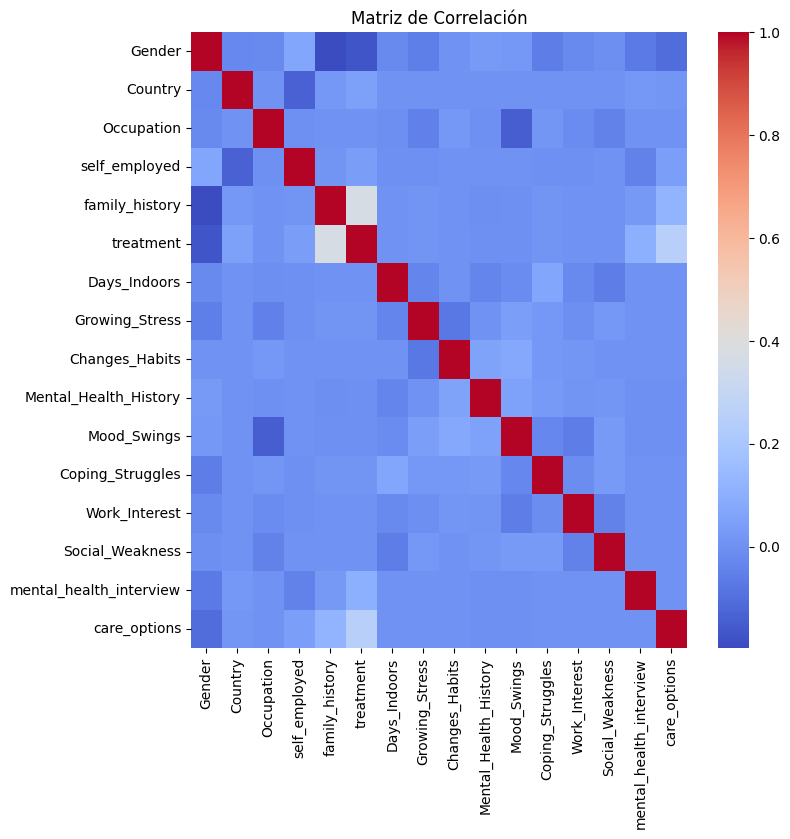

In [ ]:
plt.figure(figsize=(8, 8))
sns.heatmap(encoded_df.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

### **Definicion Variables independendientes y objetivo**

Para la variable objetivo el notebook guia toma "Mood_Swings" (que tiene 3 posibles categorias de respuesta), primero verificamos con esa, y ademas tambien planteamos que se pueden tomar como variable objetivo a "Coping_Struggles" y  "Growing_Stress". En el caso final tomamos "Coping_Struggles"

In [ ]:
df.keys()

Index(['Gender', 'Country', 'Occupation', 'self_employed', 'family_history',
       'treatment', 'Days_Indoors', 'Growing_Stress', 'Changes_Habits',
       'Mental_Health_History', 'Mood_Swings', 'Coping_Struggles',
       'Work_Interest', 'Social_Weakness', 'mental_health_interview',
       'care_options'],
      dtype='object')

In [ ]:
X = encoded_df.drop("Coping_Struggles", axis = 1)
y = encoded_df["Coping_Struggles"]

In [ ]:
print('Codificacion de:\n')
print(f'- Mood_Swings {encoders["Mood_Swings"].classes_}: \
{encoders["Mood_Swings"].transform( encoders["Mood_Swings"].classes_ )} ')

print(f'- treatment {encoders["treatment"].classes_}: \
{encoders["treatment"].transform( encoders["treatment"].classes_ )} ')

print(f'- Coping_Struggles {encoders["Coping_Struggles"].classes_}: \
{encoders["Coping_Struggles"].transform( encoders["Coping_Struggles"].classes_ )} ')

Codificacion de:

- Mood_Swings ['High' 'Low' 'Medium']: [0 1 2] 
- treatment ['No' 'Yes']: [0 1] 
- Coping_Struggles ['No' 'Yes']: [0 1] 


Distribucion de las posibles variables objetivo

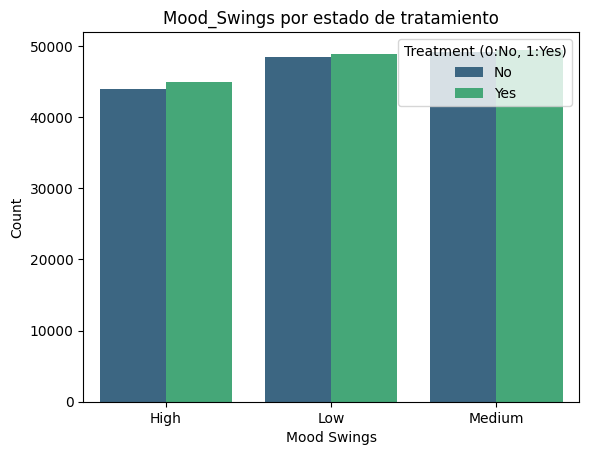

In [ ]:
plt.title('Mood_Swings por estado de tratamiento')
sns.countplot(data=encoded_df, x='Mood_Swings', hue='treatment', palette='viridis')
plt.xticks(ticks=[0,1,2], labels=['High','Low','Medium'])
plt.xlabel('Mood Swings')
plt.ylabel('Count')
plt.legend(title='Treatment (0:No, 1:Yes)', labels=['No', 'Yes'])
plt.show()

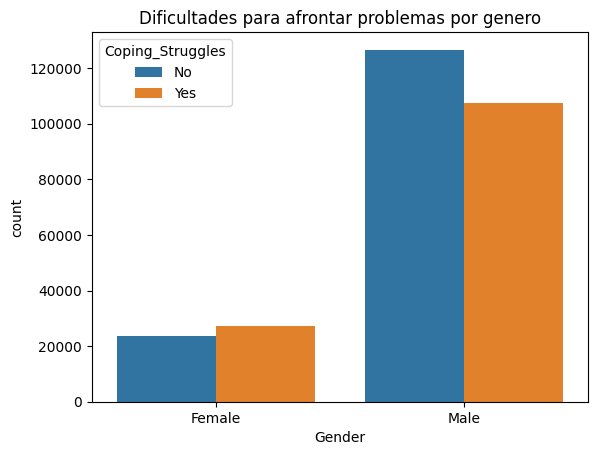

In [ ]:
plt.title('Dificultades para afrontar problemas por genero')
sns.countplot(data=df, x="Gender", hue="Coping_Struggles")
plt.show()

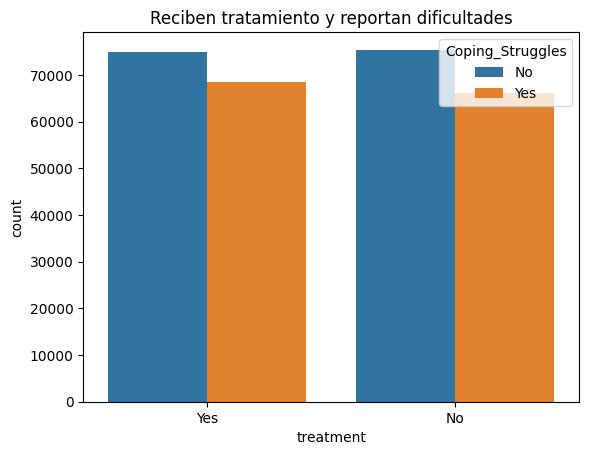

In [ ]:
plt.title('Reciben tratamiento y reportan dificultades')
sns.countplot(data=df, x="treatment", hue="Coping_Struggles")
plt.show()

### **Division de datos**

Division de los datos en entrenamiento (80%) y test (20%)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size = 0.2,
                                                     random_state = 42)

### **Aplicacion de modelos**

Funcion de "tuberia" para aplicar cada modelo. Entra como input la "lista" de los modelos, y respectivamente: se ajusta el modelo con los datos de entrenamiento, se hace la prediccion usando los datos de prueba, se aplica "cross validation" que contiene varias metricas de evaluacion de modelos (como exactitud, desviacion estandar), finalmente se aplican otras metricas como presicion, "recall", y probabiildad sobre los datos de prueba.

La funcion se tomó fundamentalmente del notebook guia, y se añadio el conteo de tiempo de demora por cada proceso, y tiempo de demora total de la aplicacion de los modelos.

In [ ]:
def pipeline_classification(pipelines):
  """
  Performs classification using cross-validation, evaluates different models,
  and makes predictions for each model on the test set.
  Args:
      pipelines --> list: List of tuples containing model names
                          and pipeline objects.
  Returns:
      pandas.DataFrame: A DataFrame containing model names, mean accuracy,
                        standard deviation, and a dictionary with test
                        set predictions for each model.
  """
  cv_results = []
  model_names = []
  model_predictions = {}
  model_probabilities = {}
  test_precision_scores = []
  test_recall_scores = []
  times = []

  for name, pipe in pipelines: # para cada modelo, lo aplica y evalua
      print(f"\n  Modelo: {name}")

      # Fit models (to the training data)
      t0 = time.perf_counter()
      pipe.fit(X_train, y_train)
      print(f"   🔹 fit(): {time.perf_counter() - t0:.2f} s")

      # Predictions (on the test set)
      t1 = time.perf_counter()
      y_pred = pipe.predict(X_test)
      model_predictions[name] = y_pred
      print(f"   🔹 predict(): {time.perf_counter() - t1:.2f} s")


      # Cross validation
      t2 = time.perf_counter()
      kfold = KFold(n_splits = 4, shuffle = True) # subdivision en 4 sets
      cv_results.append(cross_val_score(pipe, X_train, y_train,
                                        cv = kfold,
                                        scoring = 'accuracy',
                                        n_jobs = -1))
      print(f"   🔹 cross_val_score(): {time.perf_counter() - t2:.2f} s")
      # acurracy = accuracy_score(y_test, y_predict) # mas rapido-no robusto


      # Aditional metrics
      # Calculate precision & recall (for the test set (New))
      t3 = time.perf_counter()
      test_precision_scores.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
      test_recall_scores.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))
      print(f"   🔹 precision and recall(): {time.perf_counter() - t2:.2f} s")

      # Calculate probabilities on the test set
      model_probabilities[name] = pipe.predict_proba(X_test)
      model_names.append(name)

      times.append(time.perf_counter() - t0)
      print(f"   🔹 Total: {time.perf_counter() - t0:.2f} s\n")

  # Plot the cross validation results
  plt.boxplot(cv_results)
  plt.xticks(range(1, len(model_names) + 1), model_names)
  plt.title('Algorithm Comparison')
  plt.xlabel('Model')
  plt.ylabel('Accuracy')
  plt.show()

  # DataFrame of reults
  results_df = pd.DataFrame({
      'Model': model_names,
      'Mean Accuracy': [scores.mean() for scores in cv_results],
      'Standard Deviation': [scores.std() for scores in cv_results],
      'Test Precision': test_precision_scores,
      'Test Recall': test_recall_scores,
      'Total time': times})

  return results_df, model_predictions, model_probabilities

"tuberia" de modelos. contiene los nombres de los modelos y su objeto de aplicacion con la funcion Pipeline

In [ ]:
pipelines = [
  ('DT', Pipeline([ ('DT', DecisionTreeClassifier()) ]) ),
  ('RF', Pipeline([ ('RF', RandomForestClassifier(n_estimators=10)) ]) ), # por defecto usa 100 estimadores (arboles)
  ('XGB', Pipeline([ ('XGB', XGBClassifier()) ]) ),
  ('LGBM', Pipeline([('LGBM', LGBMClassifier()) ]) ),
  ('KNN', Pipeline([('scaler', MinMaxScaler()), ('KNN', KNeighborsClassifier(n_neighbors=1, algorithm='kd_tree'))])), # por defecto usa 5
  ('LR', Pipeline([('scaler', MinMaxScaler()), ('LR', LogisticRegression(max_iter=500))])),
  ('GNB', Pipeline([('scaler', MinMaxScaler()), ('GNB', GaussianNB())])),
  # ('CAT', Pipeline([('CAT', CatBoostClassifier(verbose=0))])), # se demora mucho
  # ('SVM', Pipeline([('scaler', MinMaxScaler()), ('SVM', SVC(probability=True))])), # es bueno solo si se reduce la dimensionalidad, sino interminable en tiempo
]

* Los modelos de arboles y ensambles no necesitan tener los datos reescalados con MinMaxScaler, en cambio, los modelos basados en distancias y los probabilisticos, si conviene realizar el escalamiento por eficiencia. los modelos que se quedan comentados se descartaron por su extremadamente larga duracion.

**Aplicacion del pipeline de modelos a los datos**


  Modelo: DT
   🔹 fit(): 0.71 s
   🔹 predict(): 0.01 s
   🔹 cross_val_score(): 6.37 s
   🔹 precision and recall(): 6.39 s
   🔹 Total: 7.13 s


  Modelo: RF
   🔹 fit(): 1.89 s
   🔹 predict(): 0.10 s
   🔹 cross_val_score(): 5.55 s
   🔹 precision and recall(): 5.57 s
   🔹 Total: 7.66 s


  Modelo: XGB
   🔹 fit(): 2.77 s
   🔹 predict(): 0.28 s
   🔹 cross_val_score(): 10.05 s
   🔹 precision and recall(): 10.06 s
   🔹 Total: 13.30 s


  Modelo: LGBM
[LightGBM] [Info] Number of positive: 107546, number of negative: 120340
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027205 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 77
[LightGBM] [Info] Number of data points in the train set: 227886, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.471929 -> initscore=-0.112402
[LightGBM] [Info] Start training from score -0

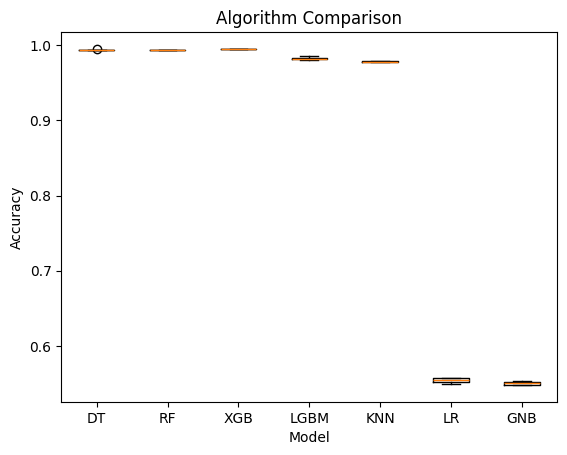

,Model,Mean Accuracy,Standard Deviation,Test Precision,Test Recall,Total time
0,DT,0.993979,0.000351,0.993243,0.993242,7.134231
1,RF,0.993979,0.000137,0.993631,0.993628,7.664668
2,XGB,0.994940,0.000188,0.994857,0.994857,13.302250
3,LGBM,0.982351,0.002322,0.980465,0.980324,15.989551
4,KNN,0.978125,0.000583,0.981572,0.981570,317.380378
5,LR,0.554189,0.003587,0.553262,0.555150,3.656966
6,GNB,0.550148,0.001906,0.551793,0.552499,1.115396


In [ ]:
results_df, model_predictions, model_probabilities = pipeline_classification(pipelines)
results_df

* Los modelos de Arboles y Ensambles tienen el mejor desempeño, evidenciamos que funcionan muy bien en el tratamiento de datos categoricos, como lo es este caso.

* el modelo KNN tiene buen desempeño, pero es mucho mas lento que los demas. Pues tiene que hacer calculo de distancias de cada punto a todos los demas, y al hacer el crossvalidation, se subdividieron los datos en 4 grupos, por lo que se repite el mismo proceso mas veces, aumentando la duracion.

* Los modelos probabilisticos y lineales tienen un mal desempeño. Pues Gaussian Bayes asume que los datos son continuos, independientes, y siguien una distribucion gaussiana, pero todos los datos que usamos son categoricos, no necesariamente independientes, ni gaussianos. Mientras que regresion logistica (RL) asume linealidad entre variables continuas y una probabilidad, pero los datos que usamos son categoricos disctretos y no lineales.



**Matrices de confusion**

In [ ]:
# funcion para graficar matriz de confusion por cada modelo
def plot_confusion_matrix(y_true, y_pred, class_names = None, cmap = "Blues", title = ""):
  """
  Plots a confusion matrix for classification tasks.
  Args:
      y_true (array-like): True labels for the data.
      y_pred (array-like): Predicted labels for the data.
      class_names (list, optional): List of class names for the labels.
      cmap (str, optional): Colormap to use for the heatmap. Defaults to 'Blues'.
      title (str, optional): Title for the confusion matrix plot. Defaults to an empty string.
  Returns:
      None
  """

  cm = confusion_matrix(y_true, y_pred)

  if class_names is None:
      class_names = np.unique(y_true)

  plt.figure()
  sns.heatmap( cm,
               annot = True,
               fmt = 'd',
               cmap = cmap,
               xticklabels = class_names,
               yticklabels = class_names)
  plt.title(f"Confusion Matrix - {model_name}")
  plt.xlabel('Predicted\n')
  plt.ylabel('True')
  plt.show()

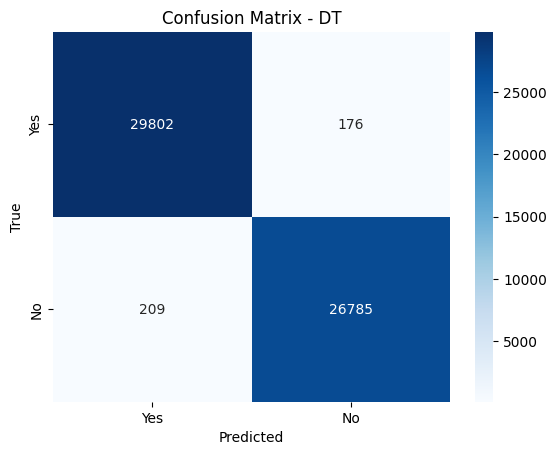

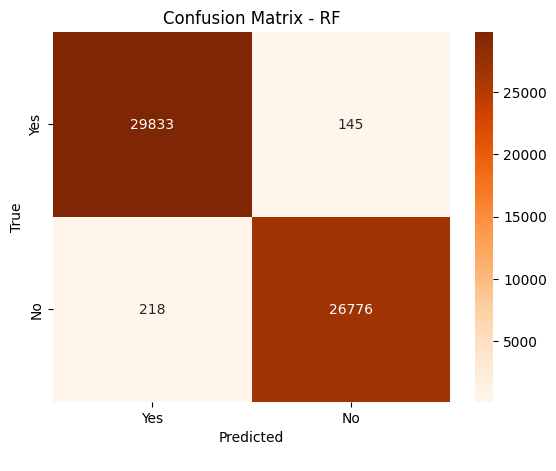

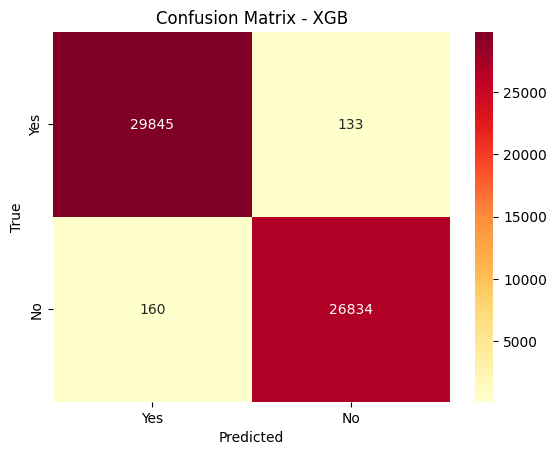

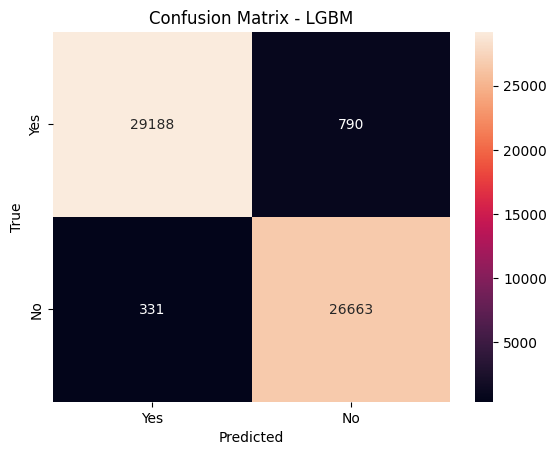

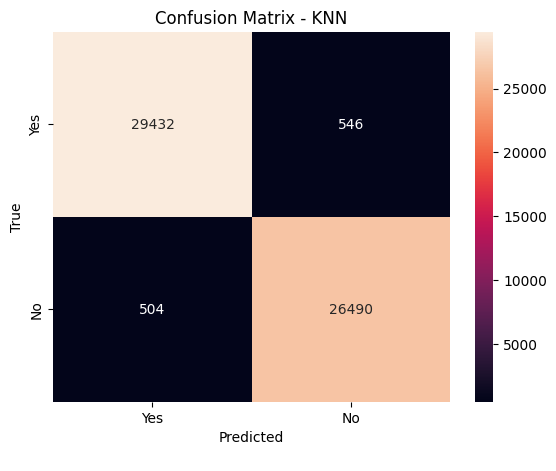

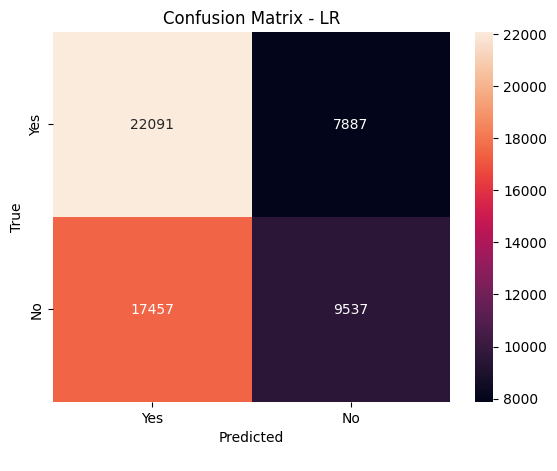

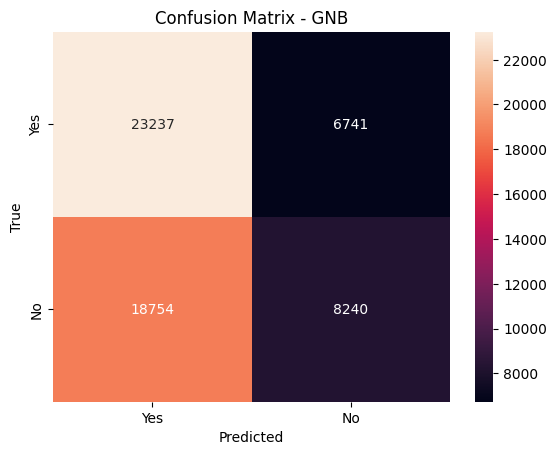

In [ ]:
# Extract model names
models = results_df.loc[:, "Model"]

# Extract model predictions
predictions = list(model_predictions.values())

# Define labels for the class outputs
labels = df["Coping_Struggles"].unique()[::-1]

# Define a dictionary mapping model names to colormaps
cmap_dict = {'DT': 'Blues', 'RF': 'Oranges', 'XGB': 'YlOrRd'}

for model_name, y_pred in zip(models, predictions):
    plot_confusion_matrix( y_test,
                         y_pred,
                         class_names = labels,
                         cmap = cmap_dict.get(model_name),
                         title = model_name)